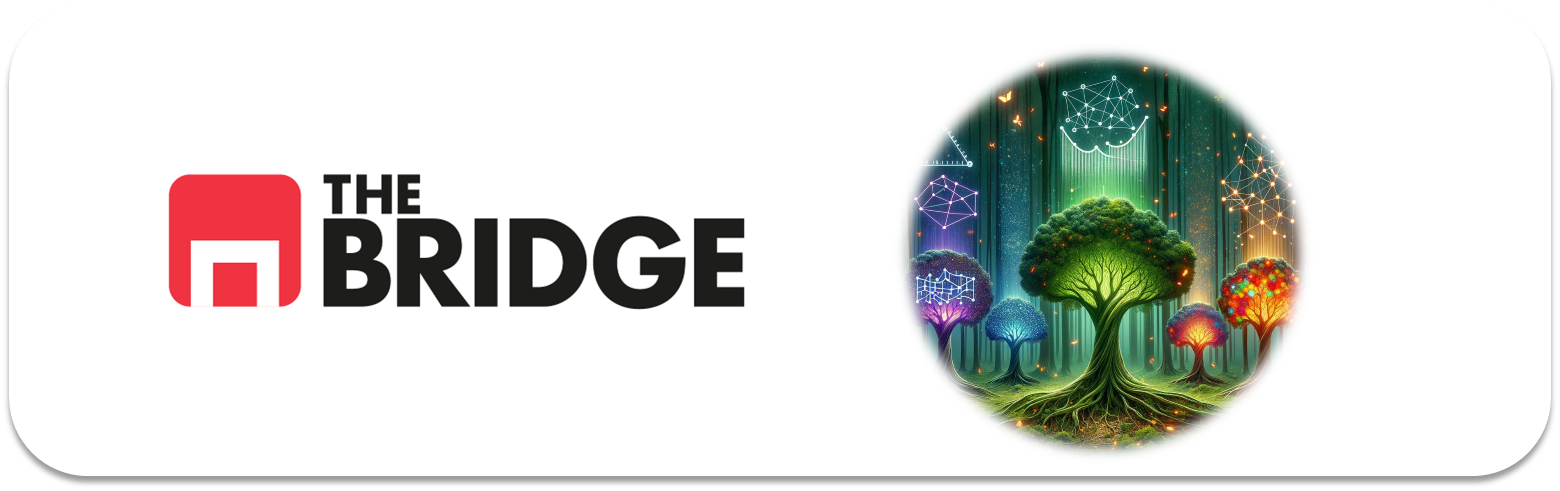

## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np
from scipy import stats

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, LabelEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.linear_model import (
    LinearRegression, LogisticRegression,
    Ridge, Lasso, ElasticNet
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor
)

# Métricas de regresión
from sklearn.metrics import (
    mean_squared_error, root_mean_squared_error,
    mean_absolute_error, r2_score
)

# Métricas de clasificación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')
pd.options.mode.copy_on_write = True


La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo. Sigue los pasos necesarios de un proceso de ML para crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

Tendrás que hacer la limpieza, split, minieda, selección, tratamiento, primeros entrenamientos, optimización, comparación y evaluación según tu mejor criterio. Eso sí, es obligatorio:
- Identificar el target y analizar su distribución
- Realizar una optimización de hiperparámetros, escogiendo un grid medianemante razonado
- Comparar con el modelo baseline
- Evaluar contra test

AYUDA: La dirección del banco nos proporciona estas notas (en inglés):

 
   **bank client data:**  
   1 - age (numeric)  
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
   4 - education (categorical: "unknown","secondary","primary","tertiary")  
   5 - default: has credit in default? (binary: "yes","no")  
   6 - balance: average yearly balance, in euros (numeric)   
   7 - housing: has housing loan? (binary: "yes","no")  
   8 - loan: has personal loan? (binary: "yes","no")   

   **related with the last contact of the current campaign:**  
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
  10 - day: last contact day of the month (numeric)  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  12 - duration: last contact duration, in seconds (numeric)    

   **other attributes:**  
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  

In [2]:
df = pd.read_csv("./data/bank-full.csv", sep = ";")
df.tail(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45201,53,management,married,tertiary,no,583,no,no,cellular,17,nov,226,1,184,4,success,yes
45202,34,admin.,single,secondary,no,557,no,no,cellular,17,nov,224,1,-1,0,unknown,yes
45203,23,student,single,tertiary,no,113,no,no,cellular,17,nov,266,1,-1,0,unknown,yes
45204,73,retired,married,secondary,no,2850,no,no,cellular,17,nov,300,1,40,8,failure,yes
45205,25,technician,single,secondary,no,505,no,yes,cellular,17,nov,386,2,-1,0,unknown,yes
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [4]:
import sys
sys.path.append(r"c:\Users\Usuario\Documents\GitHub\DS-Online-Marta-Harana\Apuntes")
from definiciones import describe_df, tipifica_variables

In [5]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
age,int64,0.0,77,0.17
job,str,0.0,12,0.03
marital,str,0.0,3,0.01
education,str,0.0,4,0.01
default,str,0.0,2,0.00
balance,int64,0.0,7168,15.85
housing,str,0.0,2,0.00
loan,str,0.0,2,0.00
contact,str,0.0,3,0.01
day,int64,0.0,31,0.07


In [6]:
TARGET = 'y'  # ← Cambia esto por el nombre de tu columna objetivo

n_unique = df[TARGET].nunique()
print(f"Valores únicos en la target: {n_unique}")

if n_unique <= 20:
    print("→ Posible CLASIFICACIÓN")
    print(df[TARGET].value_counts())
else:
    print("→ Posible REGRESIÓN")
    print(df[TARGET].describe())

Valores únicos en la target: 2
→ Posible CLASIFICACIÓN
y
no     39922
yes     5289
Name: count, dtype: int64


In [7]:
# cambiamos nuestra variable TARGET a 0 y 1

df["y"] = df["y"].map({"yes": 1, "no": 0})

In [8]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0


<Axes: >

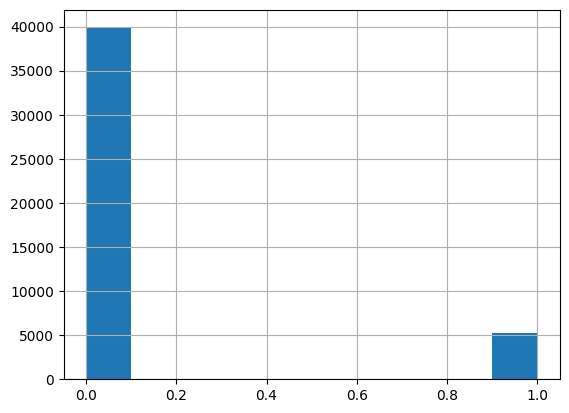

In [9]:
df[TARGET].hist()

In [10]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20 % para test
    random_state=42,     # Fija la semilla → resultados reproducibles
    stratify=y           # Descomentar en clasificación con clases desbalanceadas
)

print(f"Train: {X_train.shape[0]} filas  ({X_train.shape[0]/len(df)*100:.0f} %)")
print(f"Test:  {X_test.shape[0]} filas  ({X_test.shape[0]/len(df)*100:.0f} %)")

Train: 36168 filas  (80 %)
Test:  9043 filas  (20 %)


In [11]:
# Seleccion de features de forma automática
features_cat = X_train.select_dtypes(include="object").columns.tolist()

if TARGET in features_cat:
    features_cat.remove(TARGET)

features_cat


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

In [12]:
# Seleccionamos de forma automática
features_num = [col for col in X_train.columns if col not in features_cat and col != TARGET]
features_num

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [ ]:
# otra forma de realizarlo

Train_set, Test_set = train_test_split(
    df,
    test_size=0.2,       # 20 % para test
    random_state=42,     # Resultados reproducibles
    stratify=df[TARGET]  # Mantiene proporción de clases en train y test
)

In [13]:
# Una vez divido del data set en Train y Test, comprobamos los nulos y las filas duplicadas.

# No hay valores nulos, por lo que no tenemos que hacer ninguna imputación o eliminación.

# Comprobamos si hay filas duplicadas

df.isnull().sum()

df.duplicated().sum()

np.int64(0)

In [ ]:
# Definimos nuestra varible target, y clasificamos nuestras features en categóricas o numéricas

# features_cat = ["job", "marital", "education", "default", "housing", "loan", "contact", "poutcome", "month"]

# features_num = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]

In [ ]:
# Seleccion de features de forma automática
features_cat = Train_set.select_dtypes(include="object").columns.tolist()

if TARGET in features_cat:
    features_cat.remove(TARGET)

features_cat


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

In [19]:
# Seleccionamos de forma automática
features_num = [col for col in Train_set.columns if col not in features_cat and col != TARGET]
features_num

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

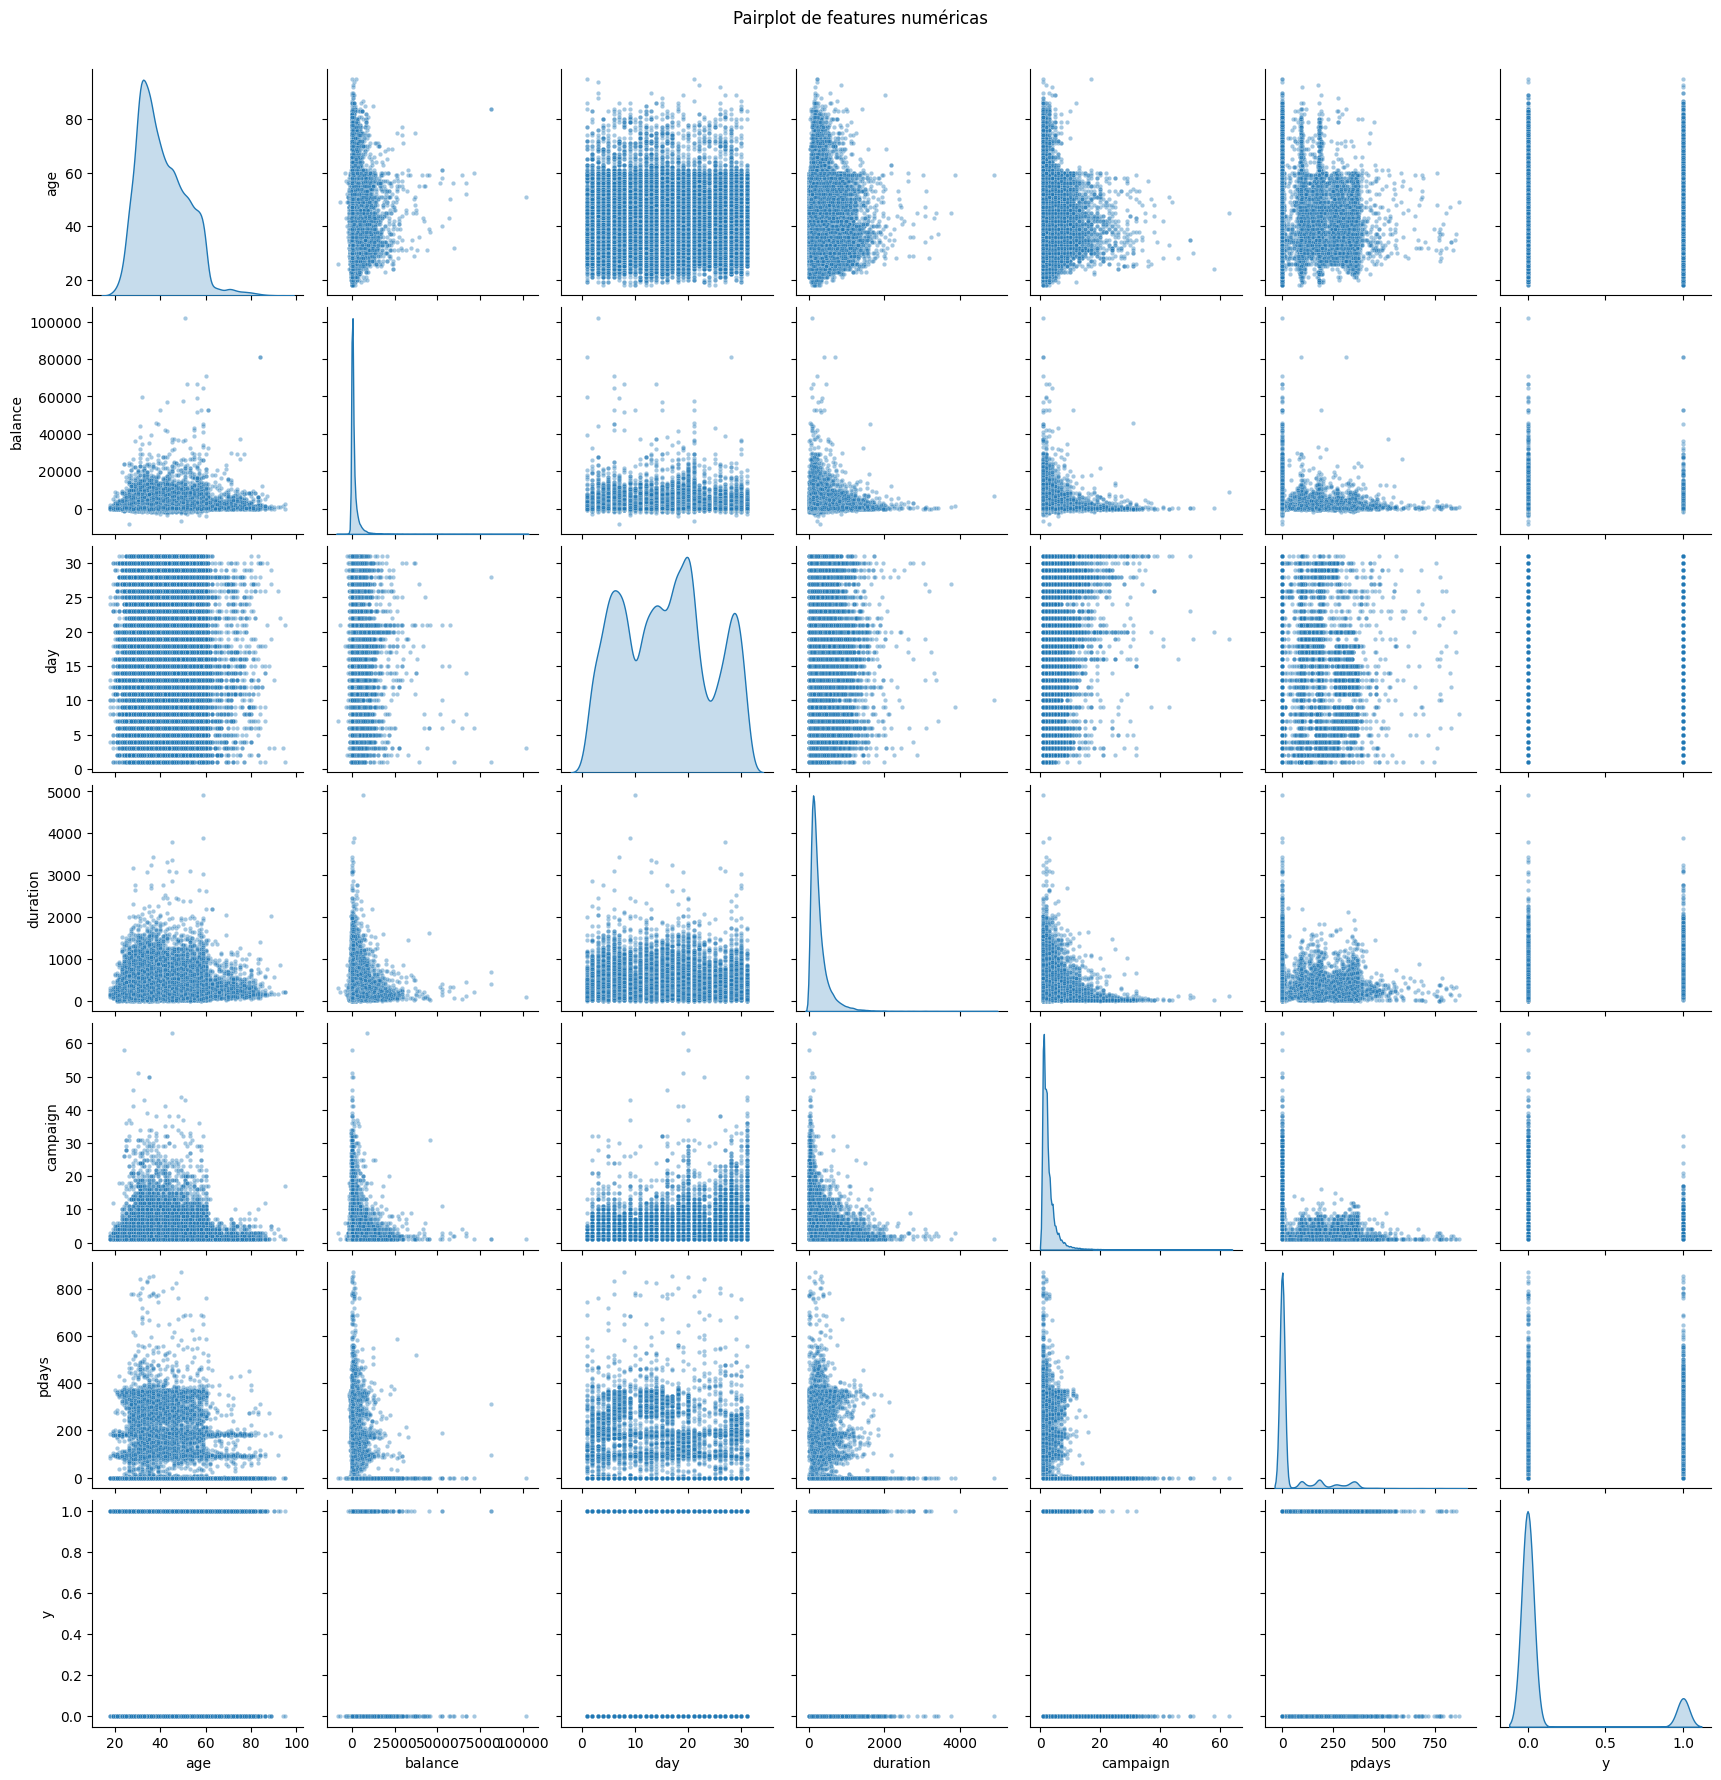

In [14]:
# Seleccionamos las features numéricas y añadimos la target

cols_plot = X_train.select_dtypes('number').columns.tolist()[:6]  # max 6 para legibilidad

sns.pairplot(
    X_train[cols_plot].join(y_train),
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 10}
)
plt.suptitle('Pairplot de features numéricas', y=1.02)
plt.show()

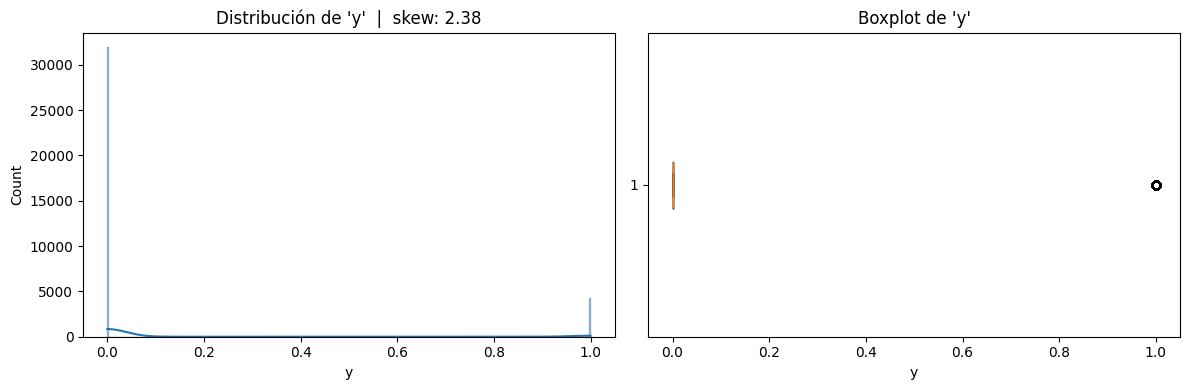

y
0    88.3
1    11.7
Name: proportion, dtype: float64


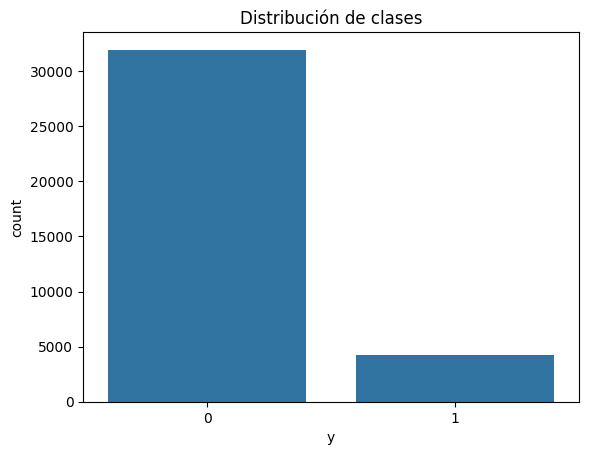

In [15]:
# Estudiamos la TARGET

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma con curva de densidad
sns.histplot(y_train, kde=True, ax=axes[0])
axes[0].set_title(f"Distribución de '{TARGET}'  |  skew: {y_train.skew():.2f}")

# Boxplot para ver outliers
axes[1].boxplot(y_train.dropna(), vert=False)
axes[1].set_title(f"Boxplot de '{TARGET}'")
axes[1].set_xlabel(TARGET)

plt.tight_layout()
plt.show()

# Para clasificación — descomenta esto:
sns.countplot(x=y_train)
plt.title('Distribución de clases')
print(y_train.value_counts(normalize=True).mul(100).round(1))

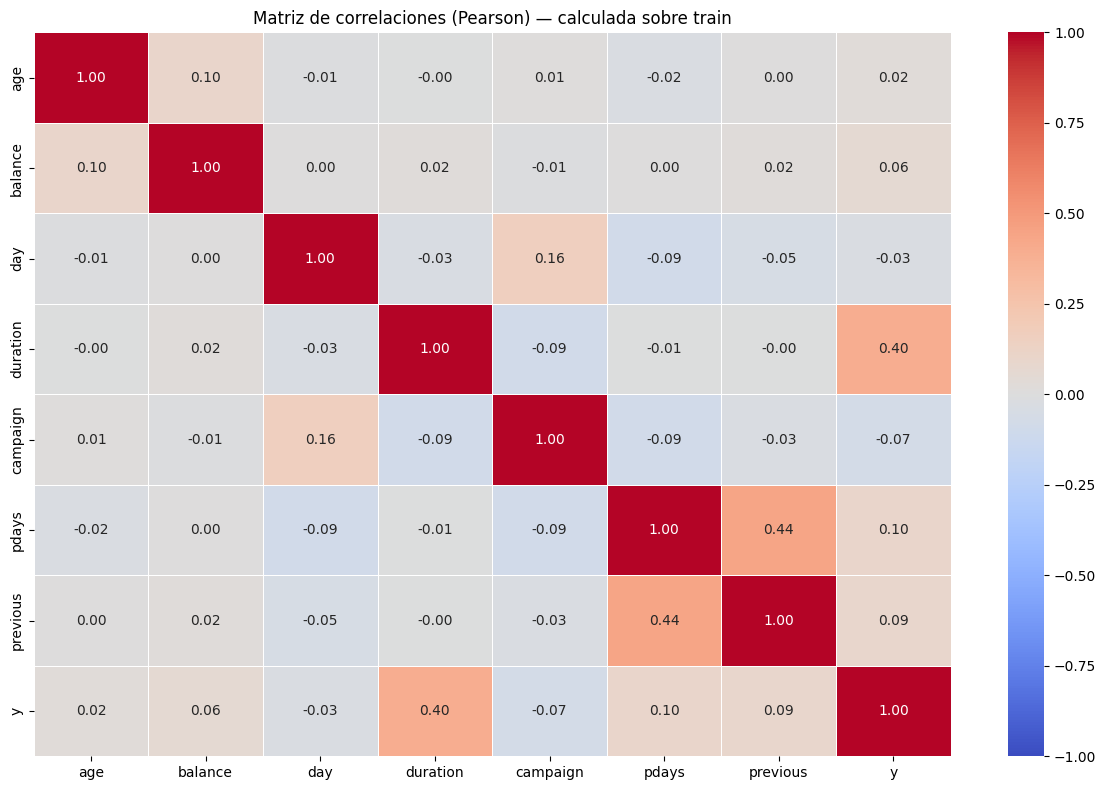


Correlación con la target:
duration    0.396742
pdays       0.100703
previous    0.088847
campaign   -0.071978
balance     0.055025
day        -0.026595
age         0.024704


In [16]:
# Hacemos la matriz de correlaciones con nuestras variables numéricas

corr = X_train.join(y_train).corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', vmin=-1, vmax=1,
            cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('Matriz de correlaciones (Pearson) — calculada sobre train')
plt.tight_layout()
plt.show()

# Correlación de cada feature con la target, ordenada
print("\nCorrelación con la target:")
print(corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).to_string())

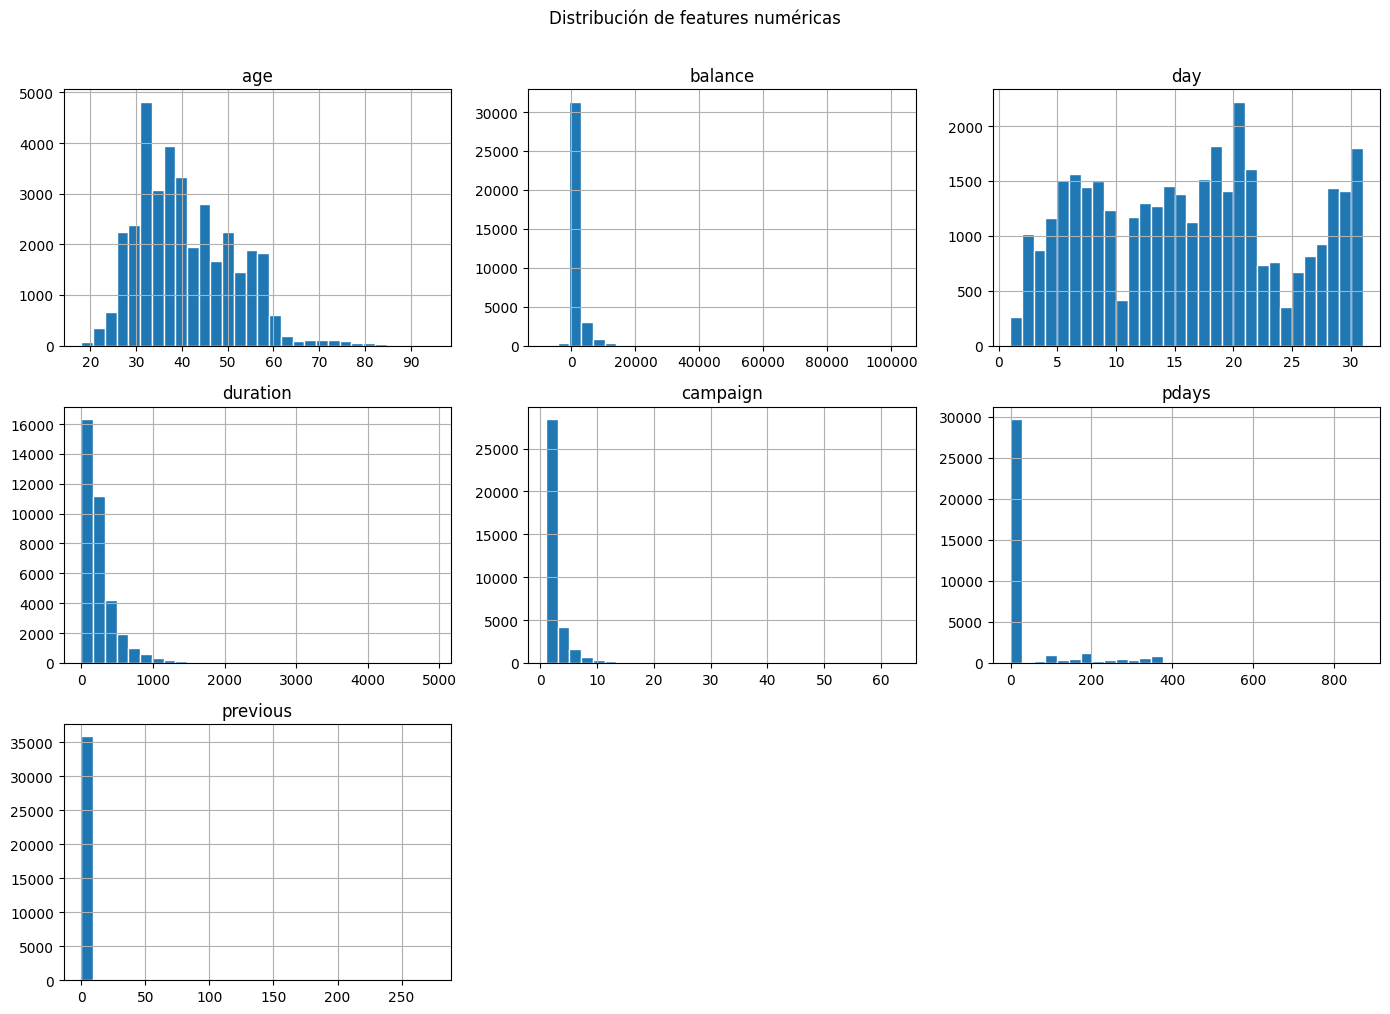

Skewness (asimetria) por feature:
previous    45.034399
balance      8.340204
campaign     4.941861
duration     3.210882
pdays        2.616298
age          0.693738
day          0.093389


In [17]:
# Análisis univariante de nuestras features numéricas

X_train.select_dtypes('number').hist(figsize=(14, 10), bins=30, edgecolor='white')
plt.suptitle('Distribución de features numéricas', y=1.01)
plt.tight_layout()
plt.show()

# Skewness de cada feature numérica
skew = X_train.select_dtypes('number').skew().sort_values(key=abs, ascending=False)
print("Skewness (asimetria) por feature:")
print(skew.to_string())

In [18]:
X_train.describe()

,age,balance,day,duration,campaign,pdays,previous
count,36168.000000,36168.00000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000
mean,40.892999,1365.49342,15.817961,258.506940,2.763935,40.157238,0.581730
std,10.627075,3068.54350,8.331980,259.142445,3.104161,100.162614,2.408766
min,18.000000,-8019.00000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,74.00000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,451.00000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1430.25000,21.000000,318.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.00000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [22]:
# asimetría alta - transformación log > 1.0

for col in ['previous', 'campaign', 'duration', 'pdays', 'balance']:
    X_train[col] = np.log1p(X_train[col])


for col in ['previous', 'campaign', 'duration', 'pdays', 'balance']:
    X_test[col] = np.log1p(X_test[col])

In [23]:
# asimetría media - transformación sqrt > 0.5

X_train['age'] = np.sqrt(X_train['age'])

X_test['age'] = np.sqrt(X_test['age'])


In [ ]:
# no aplicamos el escalado ya que los árboles de decisión no lo precisan

In [ ]:
# Elegimos la métrica antes de entrenar el modelo, ya que se trata de una target muy desbalanceada las métricas elegidas son
# Como mi target está muy desbalanceada, las métricas adecuadas son F1‑Score y PR‑AUC, porque evalúan correctamente el rendimiento 
# sobre la clase minoritaria y no se ven distorsionadas por la mayoría negativa.

In [24]:
# Aplicamos el get.dummies a todas las columnas categóricas

X_train = pd.get_dummies(
    X_train,
    columns=features_cat,
    drop_first=True,
    dtype=int
)

# aplicamos a test
X_test = pd.get_dummies(
    X_test,
    columns=features_cat,
    drop_first=True,
    dtype=int
)

In [25]:
# Comprobar dimensiones despues del get.dummies
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (36168, 42) X_test: (9043, 42)


In [ ]:
# OneHotEncoder

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [28]:
# Selección del modelo, en este caso Árbol de decisión

# Creamos el arbol y lo entrenamos
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

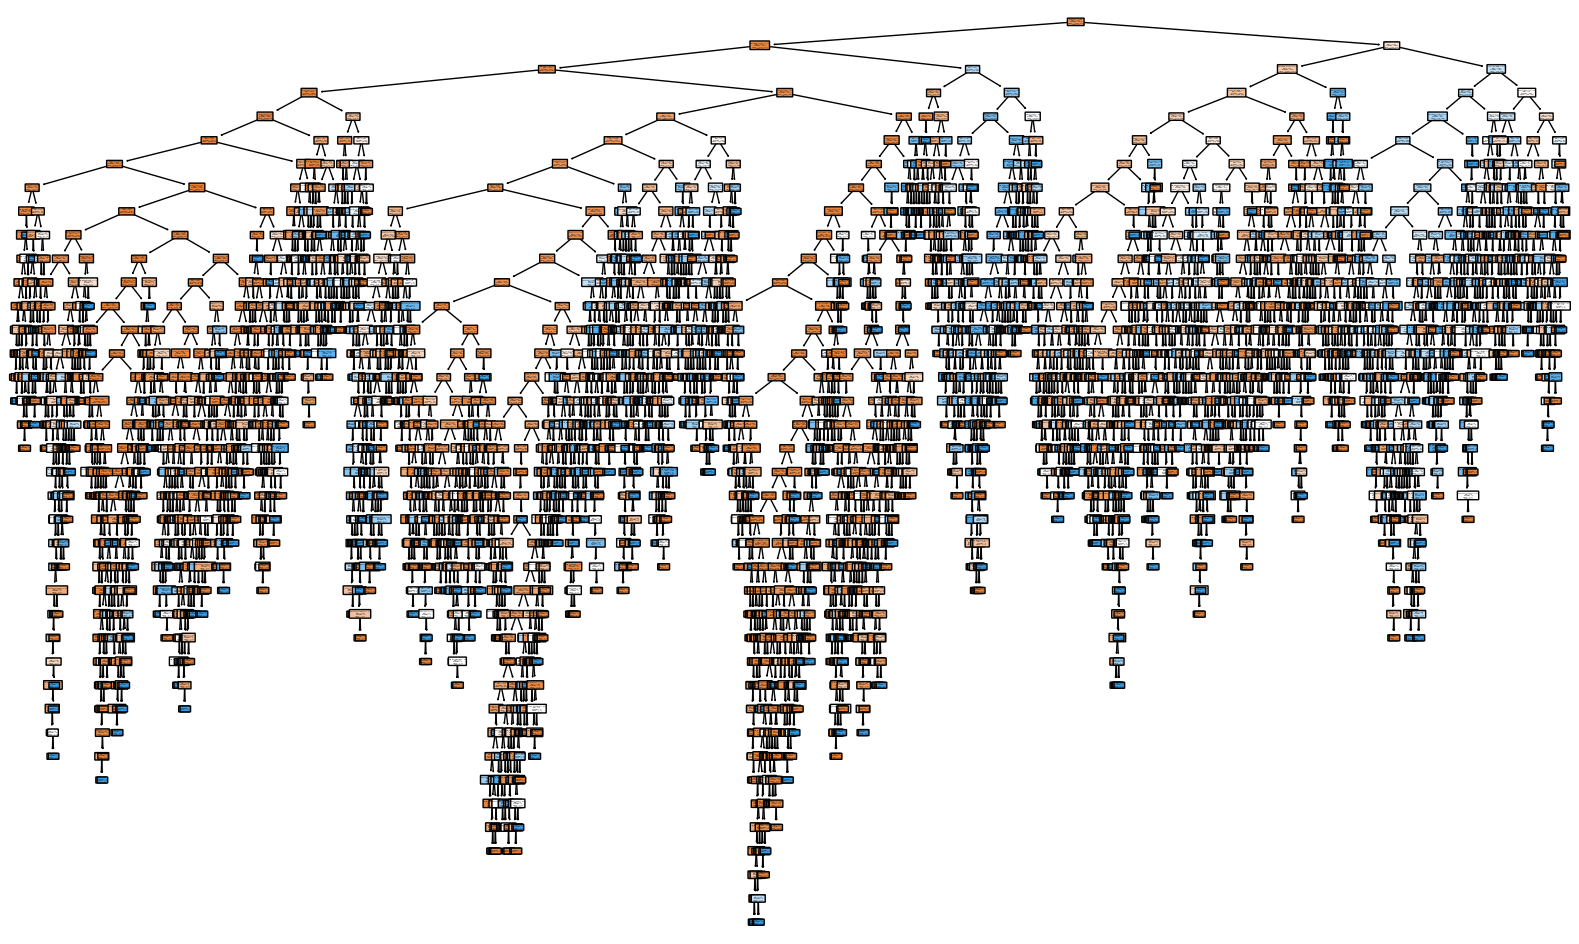

In [29]:
# visualizamos el arbol
import sklearn
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 12))
plot_tree(
    tree_clf,
    feature_names=X_train.columns,
    class_names=["no", "yes"],
    filled=True,
    rounded=True
)
plt.show()


In [30]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score
)

# Predicciones
y_pred = tree_clf.predict(X_test)
y_proba = tree_clf.predict_proba(X_test)[:, 1]   # para AUC y PR-AUC

print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))

print("\nClassification report:\n", classification_report(y_test, y_pred))

print("F1-Score (clase positiva):", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))



Matriz de confusión:
 [[7392  593]
 [ 553  505]]

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      7985
           1       0.46      0.48      0.47      1058

    accuracy                           0.87      9043
   macro avg       0.70      0.70      0.70      9043
weighted avg       0.88      0.87      0.87      9043

F1-Score (clase positiva): 0.4684601113172542
Precision: 0.4599271402550091
Recall: 0.4773156899810964

ROC-AUC: 0.7015257222604293
PR-AUC: 0.28068271276780044


In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    "max_depth": [2, 4, 6, 8, 10],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_features": ["sqrt", "log2", None],
    "class_weight": ["balanced", None]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    scoring="f1",   # F1 es la métrica correcta en desbalance
    cv=5
)

grid.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor F1 en validación:", grid.best_score_)



Mejores hiperparámetros: {'class_weight': 'balanced', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 10}
Mejor F1 en validación: 0.5328240507788589


In [33]:
best_tree = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

best_tree.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [34]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score
)

# Predicciones
y_pred = best_tree.predict(X_test)
y_proba = best_tree.predict_proba(X_test)[:, 1]

# Métricas
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))

print("\nClassification report:\n", classification_report(y_test, y_pred))

print("F1-Score (clase positiva):", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))


Matriz de confusión:
 [[6519 1466]
 [ 145  913]]

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.82      0.89      7985
           1       0.38      0.86      0.53      1058

    accuracy                           0.82      9043
   macro avg       0.68      0.84      0.71      9043
weighted avg       0.91      0.82      0.85      9043

F1-Score (clase positiva): 0.531277276694792
Precision: 0.3837746952501051
Recall: 0.8629489603024575

ROC-AUC: 0.8865210999357255
PR-AUC: 0.5283231306293602


Train Accuracy:  0.837
Test  Accuracy:  0.822
Test  Precision: 0.909
Test  Recall:    0.822
Test  F1-score:  0.848



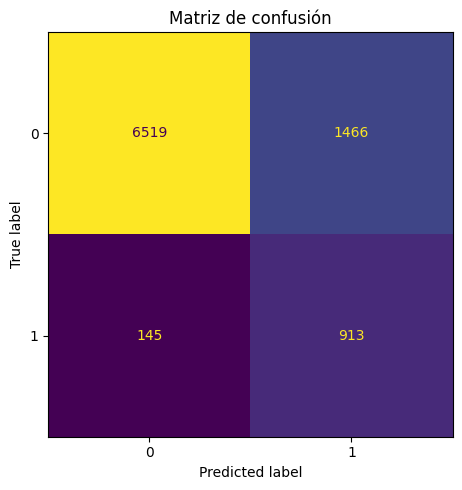

CV F1 (media ± std): 0.852 ± 0.005


In [35]:
y_train_pred = best_tree.predict(X_train)
y_test_pred  = best_tree.predict(X_test)

print(f'Train Accuracy:  {accuracy_score(y_train, y_train_pred):.3f}')
print(f'Test  Accuracy:  {accuracy_score(y_test,  y_test_pred):.3f}')
print(f'Test  Precision: {precision_score(y_test, y_test_pred, average="weighted"):.3f}')
print(f'Test  Recall:    {recall_score(y_test, y_test_pred, average="weighted"):.3f}')
print(f'Test  F1-score:  {f1_score(y_test, y_test_pred, average="weighted"):.3f}')
print()

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=ax, colorbar=False)
ax.set_title('Matriz de confusión')
plt.tight_layout()
plt.show()

# Cross-validation
cv_f1 = cross_val_score(best_tree, X_train, y_train, cv=5, scoring='f1_weighted')
print(f'CV F1 (media ± std): {cv_f1.mean():.3f} ± {cv_f1.std():.3f}')

In [ ]:
# mi objetivo es que detecte casi todos los si, por lo que tengo que mirar el recall de 1, tengo un 85%, está mucho mas ajustado.

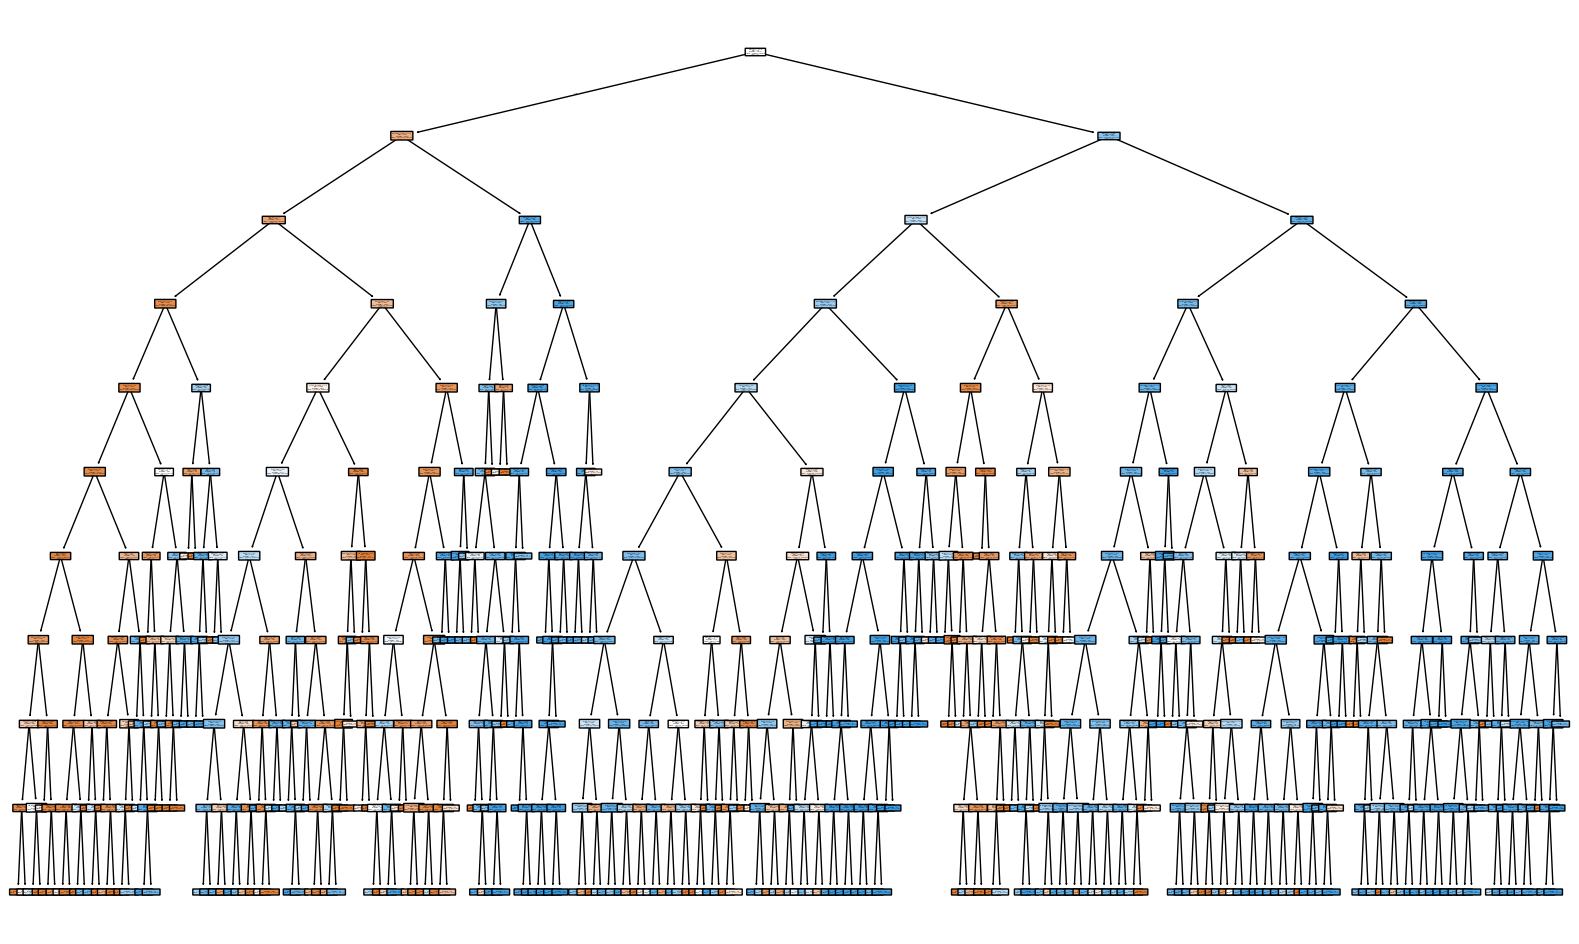

In [36]:
# visualizamos el arbol
import sklearn
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 12))
plot_tree(
    best_tree,
    feature_names=X_train.columns,
    class_names=["no", "yes"],
    filled=True,
    rounded=True
)
plt.show()